In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, clear_output
from scipy.stats import norm
from scipy import integrate
import statistics as st
import time
import sympy as sp
from scipy.integrate import quad

In [2]:
# define functions for the second bound

def sigma2_ratio(t1, t2):
    return qbar(t1) / qbar(t2)

def first_term(t):
    return sigma2_ratio(t,0)**g * init_ent

def first_term2(t):
    return sigma2_ratio(t,0)**(g - d) * init_ent

def opt_d(t):
    delta = epsilon2(t) * qbar(t) / (8 * entropy(t))
    return np.minimum(g, (1+g) * np.sqrt(delta))
    # return 0.1*g

def decay(t1, t2):
    def integrand(s):
        return g2(s) * (g - opt_d(s)) / qbar(s)
    
    integral, _ = quad(integrand, t1, t2)
    return np.exp(-integral)


def sigma2_tilde(t):
    exponent = (1 + g) / a - 1
    A = g * a / ((1 + g) - a)
    B = b - A
    return qbar(t) * (A + B * sigma2_ratio(t,0)**exponent)

def mu_tilde(t):
    exponent = (1 + g) / (2 * a)
    return u1 + sigma2_ratio(t,0)**exponent * (uT - u1)

def r_d(t):
    term1 = (1/sigma2_tilde(t) - 1/qbar(t))**2 * sigma2_tilde(t)
    term2 = ((mu_tilde(t) - u0)/qbar(t))**2
    return term1 + term2

def r_e(t):
    term1 = (1 / a - 1) * (qbar(t)- sigma2_tilde(t))
    term2 = ((1 / a - 1) * mu_tilde(t) - u1 / a + u0) * (mu_tilde(t) - u0)

    return (1 / qbar(t)**2) * (term1 - term2)

def epsilon2(t):
    term1 = (1 - 1/a) **2 * sigma2_tilde(t)
    term2 = ((mu_tilde(t) - u1)/a - mu_tilde(t) + u0)**2
    return (term1 + term2) / qbar(t)**2


def second_term(t):
    def integrand(s):
        return g2(s) * sigma2_ratio(t,s)**g * r_e(s)

    prefactor = (1 + g) / 2
    integral, _ = quad(integrand, 0, t)
    return prefactor * integral

def second_term2(t):
    def integrand(s):
        return g2(s) * sigma2_ratio(t,s)**(g - d) * epsilon2(s)

    integral, _ = quad(integrand, 0, t)
    prefactor = (1 + g)**2 / (8 * d)
    return prefactor * integral

def second_term3(t):
    def integrand(s):
        return g2(s) * decay(s, t) * epsilon2(s) / opt_d(s)

    integral, _ = quad(integrand, 0, t)
    prefactor = (1 + g)**2 / 8
    return prefactor * integral


def bound(x, type=1):
    bounds = x.copy()
    for i in range(len(x)):
        t = x[i]
        if type == 1:
            fir_term = first_term(t)
            sec_term = second_term(t)
        elif type == 2:
            fir_term = first_term2(t)
            sec_term = second_term2(t)
        elif type == 3:
            fir_term = decay(0,t) * init_ent
            sec_term = second_term3(t)
        else:
            raise ValueError("Invalid type. Please enter 1, 2 or 3.")
        bounds[i] = fir_term + sec_term
    return bounds

def entropy(x):
    def integrand(s):
        return g2(s)/2 * ((1+g) * r_e(s) - g * r_d(s))
    
    if isinstance(x, float):
        ent, _ = quad(integrand, 0, x)
    else:
        ent = x.copy()
        for i in range(len(x)):
            t = x[i]
            ent[i], _ = quad(integrand, 0, t)
    return init_ent + ent

In [3]:
# gamma
g = 5.0

# alpha
a = 0.8
# beta
b = 0.5
# T
T = 2
# mu_0
u0 = 0
# mu_theta
u1 = u0 + 0.2
# mu_T
uT = u0 + 0.5
# model (0 for VE, 1 for EDM)
model = 1

In [4]:
x = np.linspace(0.01, T, int(100*T)) - 0.01 # Adjust the range

In [5]:
if model == 1:
    def qbar(s):
        c = 1 + (T - s)**2
        return c
    
    def g2(s):
        return 2 * (T - s)
else:
    def qbar(s):
        c = 1 + T - s
        return c
    
    def g2(s):
        return 1
    
ratio = (u0 - uT)**2 / qbar(0)
init_ent = (-np.log(b) + b - 1 + ratio)/2

In [ ]:
# Compute bounds and entropy
E = entropy(x)
B1 = bound(x, 1)
d = 0.1*g
B2 = bound(x, 2)
B3 = bound(x, 3)        # this is an instantaneous optimum, which may not correspond to the optimal bound

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2834558/1921697092.py:8: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x_plot, B2, c=(1.0, 0.5, 0), label='bound 2 (darker as $\delta$ increases)')
/tmp/ipykernel_2834558/1921697092.py:16: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x_plot, B3, 'orange', linestyle='--', label='bound 2, instantaneous optimal $\delta$')


$T=2, \alpha$=0.8, $\beta$=0.5, $\mu_0$=0, $\mu_T$=0.5, $\mu_\theta$=0.2


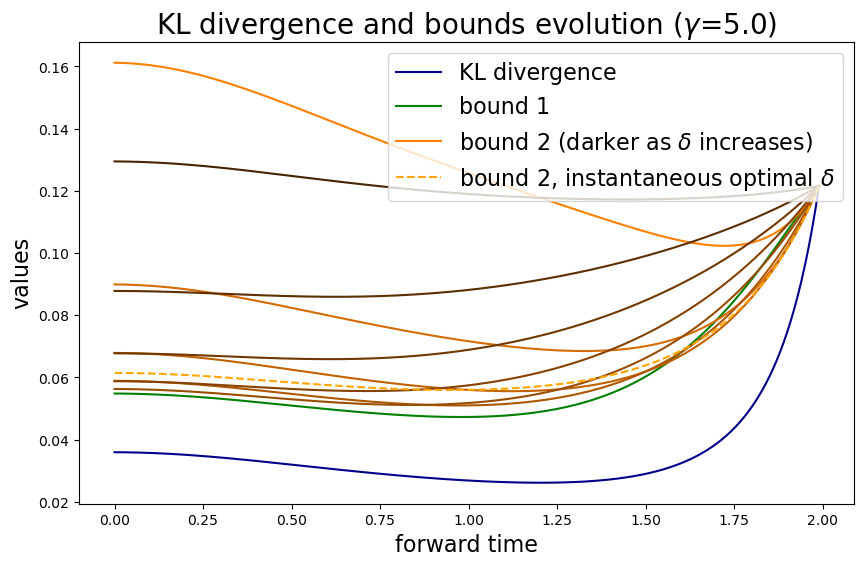

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
x_plot = np.flip(x)
fontsize = 16

ax.plot(x_plot, E, 'darkblue', label='KL divergence')
ax.plot(x_plot, B1, 'green', label='bound 1')
ax.plot(x_plot, B2, c=(1.0, 0.5, 0), label='bound 2 (darker as $\delta$ increases)')

for j in range(2, 10):
    d = j * 0.1 * g
    B2 = bound(x, 2)
    shade = 1.0 - 0.08 * j
    ax.plot(x_plot, B2, c=(shade, 0.5 * shade, 0))

ax.plot(x_plot, B3, 'orange', linestyle='--', label='bound 2, instantaneous optimal $\delta$')
ax.legend(loc="upper right", fontsize=fontsize)

# Add labels and title
ax.set_xlabel("forward time", fontsize=fontsize)
ax.set_ylabel("values", fontsize=fontsize)
ax.set_title(f"KL divergence and bounds evolution ($\\gamma$={g})", fontsize=20)
print(f'$T={T}, \\alpha$={a}, $\\beta$={b}, $\\mu_0$={u0}, $\\mu_T$={uT}, $\\mu_\\theta$={u1}')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2834558/854829627.py:2: SyntaxWarning: invalid escape sequence '\d'
  plt.title('instantaneous optimal $\delta(t)$')
/tmp/ipykernel_2834558/854829627.py:4: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$\delta$')
/tmp/ipykernel_2834558/854829627.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


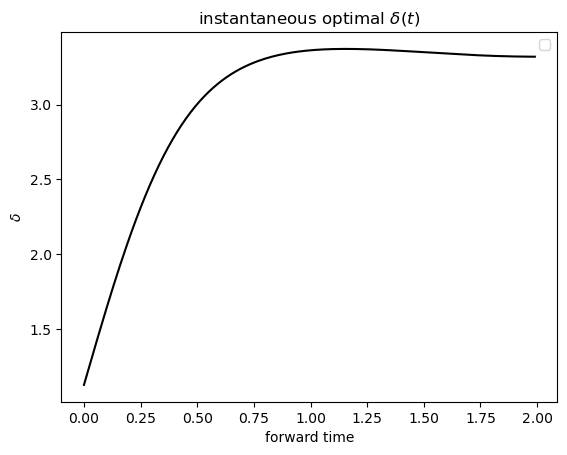

In [ ]:
plt.plot(x, opt_d(x), 'black')
plt.title('instantaneous optimal $\delta(t)$')
plt.xlabel('forward time')
plt.ylabel('$\delta$')
plt.legend()